In [1]:
import pandas as pd
from pathlib import Path

columns = ["sampling_strategy", "sample_size_per_dim", "runs_training_per_instance", "accuracy_allruns_mean", "accuracy_allruns_sd", "accuracy_median_mean", "accuracy_median_sd",
           "feval_training",
           "cv_instance_median_mean", "cv_instance_median_median",
           "cv_function_median_mean", "cv_function_median_median",
           "cv_training_folds_function_median_mean", "cv_training_folds_function_median_median",
           ]

## Dimension 2

In [2]:
table_pkl_dim2 = Path("~/t7ssd/dim2feat/classification_results/results_table.pkl")
df = pd.read_pickle(table_pkl_dim2)

| Column | Description |
|--------|-------------|
| `dimension` | Problem dimensionality (e.g. 2 or 5). |
| `sampling_strategy` | Sampling strategy used (e.g. `ilhs`, `cma_random`), parsed from the config key. |
| `sample_size_per_dim` | Base sample size per dimension. Actual sample size = `sample_size_per_dim × dimension`. |
| `feval_training` | Total function evaluations for training: `(sample_size_per_dim × dim) × 24 functions × 80 instances × n_runs_train`. |
| `runs_training_per_instance` | Number of independent runs per instance used for training (e.g. 1–30). |
| `cv_instance_median_mean` | Per-instance CV: for each feature, take the median CV across all 24×100 instances, then the **mean** across features. |
| `cv_instance_median_median` | Per-instance CV: for each feature, take the median CV across all 24×100 instances, then the **median** across features. |
| `cv_function_median_mean` | Per-function CV: for each feature, take the median CV across 24 functions, then the **mean** across features. |
| `cv_function_median_median` | Per-function CV: for each feature, take the median CV across 24 functions, then the **median** across features. |
| `cv_training_folds_function_median_mean` | Training-set CV: for each feature, take the median CV across 24 functions × 5 folds, then the **mean** across features. |
| `cv_training_folds_function_median_median` | Training-set CV: for each feature, take the median CV across 24 functions × 5 folds, then the **median** across features. |
| `accuracy_median_mean` | Mean 5-fold classification accuracy using median-aggregated features per test instance. |
| `accuracy_median_sd` | Std dev of 5-fold classification accuracy (median-aggregated features)|
| `accuracy_allruns_mean` | Mean 5-fold classification accuracy using all individual runs per test instance. |
| `accuracy_allruns_sd` | Std dev of 5-fold classification accuracy (all runs)|

In [3]:
df

,dimension,sampling_strategy,sample_size_per_dim,feval_training,runs_training_per_instance,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median,accuracy_median_mean,accuracy_median_sd,accuracy_allruns_mean,accuracy_allruns_sd
0,2,cma_random,25,96000,1,0.490284,0.479902,0.828863,0.476138,0.606822,0.459214,0.830833,0.032052,0.705403,0.009397
1,2,cma_random,25,480000,5,0.490284,0.479902,0.828863,0.476138,0.679758,0.474308,0.867500,0.017592,0.756694,0.005573
2,2,cma_random,25,960000,10,0.490284,0.479902,0.828863,0.476138,0.737390,0.470188,0.875417,0.007988,0.765611,0.006107
3,2,cma_random,25,1440000,15,0.490284,0.479902,0.828863,0.476138,0.743386,0.471599,0.875000,0.015309,0.772597,0.005898
4,2,cma_random,25,2880000,30,0.490284,0.479902,0.828863,0.476138,0.816679,0.475362,0.884583,0.006002,0.782708,0.005190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2,uniform,100,384000,1,0.198552,0.130441,0.562140,0.227195,0.380836,0.227855,0.935000,0.004751,0.919944,0.005247
96,2,uniform,100,1920000,5,0.198552,0.130441,0.562140,0.227195,0.428674,0.228117,0.937917,0.005781,0.932292,0.004285
97,2,uniform,100,3840000,10,0.198552,0.130441,0.562140,0.227195,0.461116,0.228888,0.939167,0.004517,0.933458,0.002928
98,2,uniform,100,5760000,15,0.198552,0.130441,0.562140,0.227195,0.487742,0.227413,0.940417,0.005433,0.934222,0.003681


In [4]:
df_unique = df.drop_duplicates(subset=["sampling_strategy", "sample_size_per_dim"])
pivot = df_unique.pivot(index="sampling_strategy", columns="sample_size_per_dim",
                        values="cv_instance_median_mean")
pivot

sample_size_per_dim,25,50,75,100
sampling_strategy,,,,
cma_random,0.490284,0.467463,0.490092,0.526402
ilhs,0.211366,0.174404,0.116454,0.103149
lhs,0.291499,0.237537,0.147355,0.132414
sobol,0.240613,0.161319,0.135615,0.130909
uniform,0.319444,0.261273,0.177362,0.198552


In [5]:
df["feval_training"].value_counts()


feval_training
2880000     15
960000      10
1440000     10
1920000     10
5760000     10
96000        5
480000       5
192000       5
288000       5
4320000      5
8640000      5
384000       5
3840000      5
11520000     5
Name: count, dtype: int64

In [6]:
df[df.feval_training == 96000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
20,ilhs,25,1,0.902444,0.003048,0.921250,0.004517,96000,0.211366,0.144662,0.652068,0.352993,0.441556,0.347287
60,sobol,25,1,0.897569,0.009544,0.922500,0.010142,96000,0.240613,0.194634,0.599435,0.348601,0.434660,0.346537
40,lhs,25,1,0.884347,0.008179,0.921250,0.006489,96000,0.291499,0.228625,0.718700,0.351959,0.449187,0.348700
80,uniform,25,1,0.869667,0.007772,0.911250,0.004320,96000,0.319444,0.267551,0.717137,0.369955,0.468716,0.351868
0,cma_random,25,1,0.705403,0.009397,0.830833,0.032052,96000,0.490284,0.479902,0.828863,0.476138,0.606822,0.459214


In [7]:
df[df.feval_training == 960000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)

,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
66,sobol,50,5,0.929708,0.006892,0.938750,0.009838,960000,0.161319,0.119680,0.581703,0.266705,0.441853,0.264947
46,lhs,50,5,0.929458,0.003683,0.940417,0.009152,960000,0.237537,0.161084,0.609661,0.292114,0.470104,0.296235
26,ilhs,50,5,0.929403,0.004915,0.936667,0.003785,960000,0.174404,0.093257,0.578636,0.265418,0.471926,0.268252
86,uniform,50,5,0.920667,0.005162,0.934167,0.006686,960000,0.261273,0.200384,0.658093,0.314557,0.477807,0.313772
22,ilhs,25,10,0.917958,0.005214,0.928750,0.004007,960000,0.211366,0.144662,0.652068,0.352993,0.543791,0.353646
62,sobol,25,10,0.915542,0.005397,0.931667,0.009926,960000,0.240613,0.194634,0.599435,0.348601,0.530575,0.350696
42,lhs,25,10,0.909403,0.003101,0.930417,0.006686,960000,0.291499,0.228625,0.718700,0.351959,0.557848,0.348360
82,uniform,25,10,0.897333,0.004241,0.923750,0.004796,960000,0.319444,0.267551,0.717137,0.369955,0.576240,0.374930
6,cma_random,50,5,0.814486,0.004205,0.900417,0.019676,960000,0.467463,0.457657,0.795914,0.495117,0.667594,0.490085
2,cma_random,25,10,0.765611,0.006107,0.875417,0.007988,960000,0.490284,0.479902,0.828863,0.476138,0.737390,0.470188


In [8]:
df[df.feval_training == 1440000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)

,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
31,ilhs,75,5,0.939514,0.004456,0.944167,0.007424,1440000,0.116454,0.070226,0.528328,0.232135,0.408590,0.231321
71,sobol,75,5,0.935931,0.004217,0.940833,0.002795,1440000,0.135615,0.096556,0.655604,0.231934,0.415392,0.233905
51,lhs,75,5,0.935889,0.003273,0.943750,0.003294,1440000,0.147355,0.114890,0.557796,0.231262,0.384739,0.232433
91,uniform,75,5,0.928069,0.006426,0.930833,0.007424,1440000,0.177362,0.134065,0.523513,0.228146,0.398248,0.229761
23,ilhs,25,15,0.919319,0.006588,0.932500,0.007003,1440000,0.211366,0.144662,0.652068,0.352993,0.597906,0.353889
63,sobol,25,15,0.914986,0.004722,0.930417,0.006002,1440000,0.240613,0.194634,0.599435,0.348601,0.568859,0.348976
43,lhs,25,15,0.911958,0.002882,0.928750,0.005781,1440000,0.291499,0.228625,0.718700,0.351959,0.563798,0.354021
83,uniform,25,15,0.900889,0.002717,0.927500,0.006145,1440000,0.319444,0.267551,0.717137,0.369955,0.607329,0.370779
11,cma_random,75,5,0.828472,0.005280,0.882083,0.017653,1440000,0.490092,0.529139,0.800398,0.556791,0.678545,0.551089
3,cma_random,25,15,0.772597,0.005898,0.875000,0.015309,1440000,0.490284,0.479902,0.828863,0.476138,0.743386,0.471599


In [9]:
df[df.feval_training == 1920000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
76,sobol,100,5,0.966056,0.005902,0.980000,0.005229,1920000,0.130909,0.079522,0.560618,0.229258,0.401520,0.229564
36,ilhs,100,5,0.942847,0.003138,0.945000,0.003160,1920000,0.103149,0.058256,0.551289,0.227927,0.388775,0.226610
56,lhs,100,5,0.937861,0.004050,0.945417,0.007126,1920000,0.132414,0.097792,0.660174,0.199229,0.366245,0.197134
47,lhs,50,10,0.933625,0.005421,0.940833,0.010684,1920000,0.237537,0.161084,0.609661,0.292114,0.510298,0.294117
96,uniform,100,5,0.932292,0.004285,0.937917,0.005781,1920000,0.198552,0.130441,0.562140,0.227195,0.428674,0.228117
67,sobol,50,10,0.932167,0.006460,0.937500,0.008333,1920000,0.161319,0.119680,0.581703,0.266705,0.478468,0.266208
27,ilhs,50,10,0.932028,0.004634,0.937083,0.003090,1920000,0.174404,0.093257,0.578636,0.265418,0.502562,0.264315
87,uniform,50,10,0.922722,0.005192,0.934583,0.008149,1920000,0.261273,0.200384,0.658093,0.314557,0.521185,0.311958
16,cma_random,100,5,0.834403,0.004009,0.878333,0.018376,1920000,0.526402,0.538741,0.903144,0.546156,0.746703,0.555655
7,cma_random,50,10,0.824417,0.003976,0.902083,0.008961,1920000,0.467463,0.457657,0.795914,0.495117,0.699219,0.498870


In [10]:
df[df.feval_training == 2880000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
32,ilhs,75,10,0.941181,0.005130,0.942917,0.006002,2880000,0.116454,0.070226,0.528328,0.232135,0.444839,0.233543
52,lhs,75,10,0.940181,0.003687,0.944167,0.008765,2880000,0.147355,0.114890,0.557796,0.231262,0.430399,0.230537
72,sobol,75,10,0.938111,0.005817,0.941667,0.006421,2880000,0.135615,0.096556,0.655604,0.231934,0.463572,0.233235
48,lhs,50,15,0.934764,0.004834,0.944583,0.009033,2880000,0.237537,0.161084,0.609661,0.292114,0.552214,0.291773
68,sobol,50,15,0.933972,0.006904,0.936667,0.008411,2880000,0.161319,0.119680,0.581703,0.266705,0.483229,0.269646
28,ilhs,50,15,0.933000,0.006403,0.937917,0.006815,2880000,0.174404,0.093257,0.578636,0.265418,0.521755,0.264390
92,uniform,75,10,0.931306,0.005875,0.936250,0.005229,2880000,0.177362,0.134065,0.523513,0.228146,0.418330,0.230845
88,uniform,50,15,0.925014,0.005905,0.935833,0.011449,2880000,0.261273,0.200384,0.658093,0.314557,0.564271,0.311644
24,ilhs,25,30,0.921542,0.008695,0.930833,0.009129,2880000,0.211366,0.144662,0.652068,0.352993,0.638110,0.353974
64,sobol,25,30,0.917944,0.004552,0.934167,0.007454,2880000,0.240613,0.194634,0.599435,0.348601,0.595778,0.348024


In [11]:
df[df.feval_training == 5760000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
78,sobol,100,15,0.969528,0.004112,0.979167,0.005103,5760000,0.130909,0.079522,0.560618,0.229258,0.471969,0.229060
38,ilhs,100,15,0.942222,0.005622,0.944167,0.006489,5760000,0.103149,0.058256,0.551289,0.227927,0.455845,0.229119
58,lhs,100,15,0.940444,0.004961,0.944167,0.005590,5760000,0.132414,0.097792,0.660174,0.199229,0.431507,0.198892
69,sobol,50,30,0.936944,0.008128,0.941250,0.007851,5760000,0.161319,0.119680,0.581703,0.266705,0.559249,0.268464
49,lhs,50,30,0.934917,0.004803,0.940000,0.010561,5760000,0.237537,0.161084,0.609661,0.292114,0.582382,0.292785
29,ilhs,50,30,0.934639,0.008463,0.937917,0.010664,5760000,0.174404,0.093257,0.578636,0.265418,0.546748,0.263001
98,uniform,100,15,0.934222,0.003681,0.940417,0.005433,5760000,0.198552,0.130441,0.562140,0.227195,0.487742,0.227413
89,uniform,50,30,0.927222,0.006206,0.935000,0.010865,5760000,0.261273,0.200384,0.658093,0.314557,0.615325,0.312352
18,cma_random,100,15,0.848792,0.006031,0.891667,0.010925,5760000,0.526402,0.538741,0.903144,0.546156,0.803720,0.547258
9,cma_random,50,30,0.837903,0.004550,0.910417,0.013258,5760000,0.467463,0.457657,0.795914,0.495117,0.789070,0.497040


In [31]:
df[['sampling_strategy', "sample_size_per_dim", "feval_training", "accuracy_allruns_mean", "cv_function_median_mean", "cv_training_folds_function_median_mean"]]


,sampling_strategy,sample_size_per_dim,feval_training,accuracy_allruns_mean,cv_function_median_mean,cv_training_folds_function_median_mean
0,cma_random,25,96000,0.705403,0.828863,0.606822
1,cma_random,25,480000,0.756694,0.828863,0.679758
2,cma_random,25,960000,0.765611,0.828863,0.737390
3,cma_random,25,1440000,0.772597,0.828863,0.743386
4,cma_random,25,2880000,0.782708,0.828863,0.816679
...,...,...,...,...,...,...
95,uniform,100,384000,0.919944,0.562140,0.380836
96,uniform,100,1920000,0.932292,0.562140,0.428674
97,uniform,100,3840000,0.933458,0.562140,0.461116
98,uniform,100,5760000,0.934222,0.562140,0.487742


<Axes: >

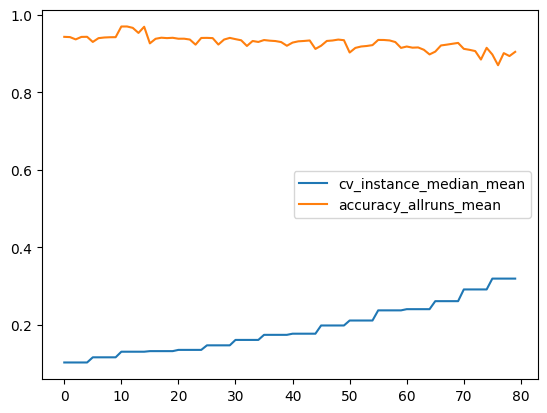

In [47]:
df[df.sampling_strategy != "cma_random"][["cv_instance_median_mean", "accuracy_allruns_mean"]].sort_values(by=["cv_instance_median_mean"]).reset_index(drop=True).plot()

In [12]:
df["accuracy_per_million_feval"] = df["accuracy_median_mean"] / (df["feval_training"] / 1e6)

In [13]:
# Best config per strategy (highest accuracy)
df.loc[df.groupby("sampling_strategy")["accuracy_median_mean"].idxmax()]

,dimension,sampling_strategy,sample_size_per_dim,feval_training,runs_training_per_instance,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median,accuracy_median_mean,accuracy_median_sd,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_per_million_feval
9,2,cma_random,50,5760000,30,0.467463,0.457657,0.795914,0.495117,0.789070,0.497040,0.910417,0.013258,0.837903,0.004550,0.158058
36,2,ilhs,100,1920000,5,0.103149,0.058256,0.551289,0.227927,0.388775,0.226610,0.945000,0.003160,0.942847,0.003138,0.492188
56,2,lhs,100,1920000,5,0.132414,0.097792,0.660174,0.199229,0.366245,0.197134,0.945417,0.007126,0.937861,0.004050,0.492405
77,2,sobol,100,3840000,10,0.130909,0.079522,0.560618,0.229258,0.438481,0.230293,0.980833,0.002282,0.968889,0.003434,0.255425
98,2,uniform,100,5760000,15,0.198552,0.130441,0.562140,0.227195,0.487742,0.227413,0.940417,0.005433,0.934222,0.003681,0.163267


In [14]:
# Most efficient config per strategy (cheapest within 1% of best)
for s in df["sampling_strategy"].unique():
    sub = df[df["sampling_strategy"] == s]
    threshold = sub["accuracy_median_mean"].max() - 0.01
    print(sub[sub["accuracy_median_mean"] >= threshold].sort_values("feval_training").iloc[0])
    print()

dimension                                            2
sampling_strategy                           cma_random
sample_size_per_dim                                 50
feval_training                                 1920000
runs_training_per_instance                          10
cv_instance_median_mean                       0.467463
cv_instance_median_median                     0.457657
cv_function_median_mean                       0.795914
cv_function_median_median                     0.495117
cv_training_folds_function_median_mean        0.699219
cv_training_folds_function_median_median       0.49887
accuracy_median_mean                          0.902083
accuracy_median_sd                            0.008961
accuracy_allruns_mean                         0.824417
accuracy_allruns_sd                           0.003976
accuracy_per_million_feval                    0.469835
Name: 7, dtype: object

dimension                                          2
sampling_strategy                          

## Dimension 5

In [15]:
table_pkl_dim5 = Path("~/t7ssd/dim5featEla/classification_results/results_table.pkl")
df_dim5 = pd.read_pickle(table_pkl_dim5)
df_dim5 = df_dim5.drop(df_dim5[df_dim5.sample_size_per_dim == 10].index)
df_dim5


,dimension,sampling_strategy,sample_size_per_dim,feval_training,runs_training_per_instance,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median,accuracy_median_mean,accuracy_median_sd,accuracy_allruns_mean,accuracy_allruns_sd
5,5,cma_random,25,240000,1,0.358806,0.332018,0.701261,0.342616,0.448946,0.336945,0.964583,0.015095,0.843097,0.003477
6,5,cma_random,25,1200000,5,0.358806,0.332018,0.701261,0.342616,0.522187,0.338940,0.985833,0.004007,0.886639,0.002859
7,5,cma_random,25,2400000,10,0.358806,0.332018,0.701261,0.342616,0.551509,0.339881,0.988750,0.009501,0.896972,0.001457
8,5,cma_random,25,3600000,15,0.358806,0.332018,0.701261,0.342616,0.572626,0.339098,0.989583,0.006421,0.902236,0.001641
9,5,cma_random,25,7200000,30,0.358806,0.332018,0.701261,0.342616,0.646015,0.342516,0.991667,0.004419,0.908764,0.002187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,5,uniform,100,960000,1,0.185245,0.081503,0.539473,0.113519,0.295931,0.112295,0.987083,0.004270,0.974444,0.003216
121,5,uniform,100,4800000,5,0.185245,0.081503,0.539473,0.113519,0.344583,0.111899,0.992500,0.003160,0.979875,0.002825
122,5,uniform,100,9600000,10,0.185245,0.081503,0.539473,0.113519,0.384293,0.113944,0.990000,0.004007,0.980028,0.002976
123,5,uniform,100,14400000,15,0.185245,0.081503,0.539473,0.113519,0.401566,0.113721,0.991667,0.005311,0.981153,0.003357


In [16]:
df_unique = df_dim5.drop_duplicates(subset=["sampling_strategy", "sample_size_per_dim"])
pivot = df_unique.pivot(index="sampling_strategy", columns="sample_size_per_dim",
                        values="cv_instance_median_mean")
pivot

sample_size_per_dim,25,50,75,100
sampling_strategy,,,,
cma_random,0.358806,0.384086,0.398968,0.428547
ilhs,0.231247,0.177530,0.151934,0.130748
lhs,0.264961,0.213222,0.192445,0.179243
sobol,0.227215,0.177535,0.156443,0.125253
uniform,0.263006,0.218350,0.198319,0.185245


In [17]:
df_dim5["feval_training"].value_counts()


feval_training
7200000     15
2400000     10
3600000     10
4800000     10
14400000    10
240000       5
1200000      5
480000       5
720000       5
10800000     5
21600000     5
960000       5
9600000      5
28800000     5
Name: count, dtype: int64

In [18]:
df_dim5[df_dim5.feval_training == 2400000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
36,ilhs,50,5,0.972583,0.002930,0.985833,0.006319,2400000,0.177530,0.069611,0.502704,0.118135,0.372047,0.116468
86,sobol,50,5,0.972153,0.002210,0.986250,0.003160,2400000,0.177535,0.066933,0.507338,0.114481,0.368600,0.113894
61,lhs,50,5,0.967444,0.002863,0.983750,0.004517,2400000,0.213222,0.090330,0.506478,0.150046,0.376796,0.149465
111,uniform,50,5,0.967319,0.002133,0.984167,0.006686,2400000,0.218350,0.113557,0.500128,0.154165,0.383381,0.152560
32,ilhs,25,10,0.961222,0.001544,0.972500,0.005393,2400000,0.231247,0.105629,0.537161,0.165949,0.469152,0.163279
82,sobol,25,10,0.961153,0.002520,0.977083,0.007065,2400000,0.227215,0.102832,0.544983,0.164321,0.457158,0.162522
107,uniform,25,10,0.955083,0.003428,0.982500,0.010479,2400000,0.263006,0.158221,0.586816,0.209672,0.458996,0.208519
57,lhs,25,10,0.954194,0.003062,0.973750,0.006847,2400000,0.264961,0.127125,0.600419,0.196763,0.489664,0.187229
11,cma_random,50,5,0.920528,0.001690,0.980000,0.004320,2400000,0.384086,0.340238,0.700045,0.374668,0.549830,0.371551
7,cma_random,25,10,0.896972,0.001457,0.988750,0.009501,2400000,0.358806,0.332018,0.701261,0.342616,0.551509,0.339881


In [19]:
df_dim5[df_dim5.feval_training == 3600000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
91,sobol,75,5,0.978875,0.002070,0.988750,0.003160,3600000,0.156443,0.054163,0.549950,0.095629,0.352977,0.095223
41,ilhs,75,5,0.978194,0.002723,0.989583,0.002946,3600000,0.151934,0.054805,0.553480,0.095635,0.380271,0.094377
66,lhs,75,5,0.976167,0.002156,0.989583,0.004658,3600000,0.192445,0.073392,0.480690,0.123318,0.358790,0.121688
116,uniform,75,5,0.973986,0.001044,0.986667,0.001863,3600000,0.198319,0.094673,0.587915,0.128279,0.357852,0.126713
83,sobol,25,15,0.962361,0.002167,0.977917,0.006002,3600000,0.227215,0.102832,0.544983,0.164321,0.506383,0.163252
33,ilhs,25,15,0.962250,0.001705,0.975000,0.003898,3600000,0.231247,0.105629,0.537161,0.165949,0.504085,0.163214
108,uniform,25,15,0.955486,0.003997,0.983333,0.008961,3600000,0.263006,0.158221,0.586816,0.209672,0.502383,0.208257
58,lhs,25,15,0.955250,0.003959,0.976250,0.007739,3600000,0.264961,0.127125,0.600419,0.196763,0.500562,0.188792
16,cma_random,75,5,0.928972,0.000782,0.968750,0.011411,3600000,0.398968,0.343053,0.732610,0.360258,0.577345,0.362489
8,cma_random,25,15,0.902236,0.001641,0.989583,0.006421,3600000,0.358806,0.332018,0.701261,0.342616,0.572626,0.339098


In [20]:
df_dim5[df_dim5.feval_training == 4800000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
96,sobol,100,5,0.981903,0.001759,0.989167,0.001743,4800000,0.125253,0.042228,0.656888,0.090097,0.344357,0.088619
46,ilhs,100,5,0.981736,0.002177,0.991250,0.001743,4800000,0.130748,0.046260,0.498696,0.090954,0.325592,0.092154
121,uniform,100,5,0.979875,0.002825,0.992500,0.003160,4800000,0.185245,0.081503,0.539473,0.113519,0.344583,0.111899
71,lhs,100,5,0.979278,0.000912,0.988750,0.003785,4800000,0.179243,0.063417,0.541712,0.108970,0.351485,0.110084
37,ilhs,50,10,0.974111,0.003134,0.985000,0.005393,4800000,0.177530,0.069611,0.502704,0.118135,0.402206,0.118681
87,sobol,50,10,0.973514,0.001559,0.986250,0.003486,4800000,0.177535,0.066933,0.507338,0.114481,0.420888,0.114105
62,lhs,50,10,0.969000,0.002146,0.982083,0.002375,4800000,0.213222,0.090330,0.506478,0.150046,0.400993,0.148815
112,uniform,50,10,0.968236,0.001680,0.985833,0.006489,4800000,0.218350,0.113557,0.500128,0.154165,0.406682,0.153178
21,cma_random,100,5,0.946014,0.002204,0.988333,0.003785,4800000,0.428547,0.351276,0.734767,0.357180,0.600741,0.362147
12,cma_random,50,10,0.927931,0.001479,0.986667,0.005629,4800000,0.384086,0.340238,0.700045,0.374668,0.573201,0.373516


In [21]:
df_dim5[df_dim5.feval_training == 7200000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
92,sobol,75,10,0.979556,0.002052,0.989167,0.004517,7200000,0.156443,0.054163,0.549950,0.095629,0.399361,0.095016
42,ilhs,75,10,0.979167,0.002789,0.989583,0.005103,7200000,0.151934,0.054805,0.553480,0.095635,0.417286,0.096197
67,lhs,75,10,0.977333,0.001485,0.991250,0.002716,7200000,0.192445,0.073392,0.480690,0.123318,0.403146,0.124634
117,uniform,75,10,0.975444,0.001978,0.990000,0.003090,7200000,0.198319,0.094673,0.587915,0.128279,0.405933,0.126739
38,ilhs,50,15,0.974347,0.002549,0.985833,0.004974,7200000,0.177530,0.069611,0.502704,0.118135,0.419029,0.118565
88,sobol,50,15,0.973444,0.001605,0.984167,0.003160,7200000,0.177535,0.066933,0.507338,0.114481,0.466550,0.113686
63,lhs,50,15,0.970000,0.003162,0.985000,0.003090,7200000,0.213222,0.090330,0.506478,0.150046,0.398516,0.149059
113,uniform,50,15,0.969056,0.001146,0.985000,0.004517,7200000,0.218350,0.113557,0.500128,0.154165,0.436695,0.153672
34,ilhs,25,30,0.964097,0.002134,0.973750,0.004061,7200000,0.231247,0.105629,0.537161,0.165949,0.524120,0.163856
84,sobol,25,30,0.963819,0.002656,0.979583,0.004974,7200000,0.227215,0.102832,0.544983,0.164321,0.531527,0.163962


In [22]:
df_dim5[df_dim5.feval_training == 14400000][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)


,sampling_strategy,sample_size_per_dim,runs_training_per_instance,accuracy_allruns_mean,accuracy_allruns_sd,accuracy_median_mean,accuracy_median_sd,feval_training,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median
98,sobol,100,15,0.983153,0.001777,0.990833,0.001141,14400000,0.125253,0.042228,0.656888,0.090097,0.426084,0.089135
48,ilhs,100,15,0.982583,0.002923,0.990000,0.004007,14400000,0.130748,0.046260,0.498696,0.090954,0.419238,0.091316
123,uniform,100,15,0.981153,0.003357,0.991667,0.005311,14400000,0.185245,0.081503,0.539473,0.113519,0.401566,0.113721
73,lhs,100,15,0.980486,0.001747,0.990000,0.002716,14400000,0.179243,0.063417,0.541712,0.108970,0.416542,0.108545
89,sobol,50,30,0.974792,0.002275,0.983333,0.001473,14400000,0.177535,0.066933,0.507338,0.114481,0.502484,0.115097
39,ilhs,50,30,0.974778,0.002839,0.985417,0.006074,14400000,0.177530,0.069611,0.502704,0.118135,0.479890,0.118915
64,lhs,50,30,0.970847,0.003149,0.985000,0.002282,14400000,0.213222,0.090330,0.506478,0.150046,0.492916,0.149249
114,uniform,50,30,0.970458,0.001381,0.985000,0.004751,14400000,0.218350,0.113557,0.500128,0.154165,0.475379,0.152664
23,cma_random,100,15,0.956097,0.001175,0.989583,0.003898,14400000,0.428547,0.351276,0.734767,0.357180,0.665111,0.354835
14,cma_random,50,30,0.937931,0.002014,0.982083,0.006002,14400000,0.384086,0.340238,0.700045,0.374668,0.686376,0.373827


In [23]:
# Best config per strategy (highest accuracy)
df_dim5.loc[df_dim5.groupby("sampling_strategy")["accuracy_median_mean"].idxmax()]

,dimension,sampling_strategy,sample_size_per_dim,feval_training,runs_training_per_instance,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_function_median_mean,cv_training_folds_function_median_median,accuracy_median_mean,accuracy_median_sd,accuracy_allruns_mean,accuracy_allruns_sd
9,5,cma_random,25,7200000,30,0.358806,0.332018,0.701261,0.342616,0.646015,0.342516,0.991667,0.004419,0.908764,0.002187
46,5,ilhs,100,4800000,5,0.130748,0.046260,0.498696,0.090954,0.325592,0.092154,0.991250,0.001743,0.981736,0.002177
69,5,lhs,75,21600000,30,0.192445,0.073392,0.480690,0.123318,0.458359,0.122916,0.992917,0.001863,0.978875,0.001734
98,5,sobol,100,14400000,15,0.125253,0.042228,0.656888,0.090097,0.426084,0.089135,0.990833,0.001141,0.983153,0.001777
121,5,uniform,100,4800000,5,0.185245,0.081503,0.539473,0.113519,0.344583,0.111899,0.992500,0.003160,0.979875,0.002825


In [24]:
correlation_dim2_pkl_path = Path("~/t7ssd/dim2feat/classification_results/correlation_studies.pkl")


In [25]:
import pickle
from pathlib import Path

with open(Path("~/t7ssd/dim2feat/classification_results/correlation_studies.pkl").expanduser(), "rb") as f:
    results = pickle.load(f)

results["summary"].drop(columns=["study"])

,x_variable,y_variable,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,per_instance_consistency_mean,cv_instance_median_mean,100,-0.901699,1.830258e-37,-0.913188,5.500188e-40
1,per_instance_consistency_mean,cv_instance_median_median,100,-0.903504,7.717412e-38,-0.895285,3.457562e-36
2,cv_instance_median_mean,accuracy_mean,100,-0.874462,1.489712e-32,-0.890787,2.428234e-35
3,cv_instance_median_median,accuracy_mean,100,-0.880728,1.417146e-33,-0.870327,6.572163e-32
4,cv_function_median_mean,accuracy_mean,100,-0.814423,6.730276e-25,-0.708243,1.705264e-16
5,cv_function_median_median,accuracy_mean,100,-0.850440,4.329362e-29,-0.835777,2.915252e-27
6,cv_instance_median_mean,accuracy_sd,100,0.537627,8.034325e-09,0.318400,1.244726e-03
7,cv_instance_median_median,accuracy_sd,100,0.551894,2.653581e-09,0.337026,6.063201e-04
8,cv_training_func_median_mean,accuracy_mean,100,-0.636770,1.069977e-12,-0.590682,9.877847e-11
9,cv_training_func_median_median,accuracy_mean,100,-0.843301,3.547289e-28,-0.832409,7.233472e-27


In [26]:
results['stratified'].drop(columns=["study"])

,stratification,x_variable,y_variable,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,dim=2,consistency_mean,cv_instance_median_mean,100,-0.901699,1.830258e-37,-0.913188,5.500188e-40
1,dim=2,cv_instance_median_mean,accuracy_mean,100,-0.874462,1.489712e-32,-0.890787,2.428234e-35
2,dim=2,cv_function_median_mean,accuracy_mean,100,-0.814423,6.730276e-25,-0.708243,1.705264e-16
3,dim=2,cv_instance_median_mean,accuracy_sd,100,0.537627,8.034325e-09,0.318400,1.244726e-03
4,dim=2,cv_training_func_median_mean,accuracy_mean,100,-0.636770,1.069977e-12,-0.590682,9.877847e-11
...,...,...,...,...,...,...,...,...
61,strategy=uniform,cv_instance_median_mean,accuracy_allruns_mean,20,-0.796334,2.661493e-05,-0.729033,2.657508e-04
62,strategy=uniform,cv_function_median_mean,accuracy_allruns_mean,20,-0.756590,1.130966e-04,-0.729033,2.657508e-04
63,strategy=uniform,cv_instance_median_mean,accuracy_allruns_sd,20,-0.097569,6.823741e-01,-0.224914,3.404007e-01
64,strategy=uniform,cv_training_func_median_mean,accuracy_allruns_mean,20,-0.211970,3.696259e-01,-0.193985,4.125038e-01


In [27]:
import pickle
from pathlib import Path

with open(Path("~/t7ssd/dim5featEla/classification_results/correlation_studies.pkl").expanduser(), "rb") as f:
    results_dim5 = pickle.load(f)

results_dim5["summary"].drop(columns=["study"])

,x_variable,y_variable,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,per_instance_consistency_mean,cv_instance_median_mean,100,-0.787675,2.462742e-22,-0.895317,3.407771e-36
1,per_instance_consistency_mean,cv_instance_median_median,100,-0.823588,7.125062e-26,-0.893575,7.328024e-36
2,cv_instance_median_mean,accuracy_mean,100,-0.379850,9.703341e-05,-0.494786,1.670922e-07
3,cv_instance_median_median,accuracy_mean,100,-0.295417,2.845759e-03,-0.474531,6.108860e-07
4,cv_function_median_mean,accuracy_mean,100,-0.200203,4.581124e-02,-0.152367,1.301879e-01
5,cv_function_median_median,accuracy_mean,100,-0.367151,1.716446e-04,-0.549782,3.136788e-09
6,cv_instance_median_mean,accuracy_sd,100,0.506160,7.772089e-08,0.510776,5.651053e-08
7,cv_instance_median_median,accuracy_sd,100,0.481342,3.987121e-07,0.532044,1.222383e-08
8,cv_training_func_median_mean,accuracy_mean,125,-0.204364,2.224891e-02,-0.241821,6.589155e-03
9,cv_training_func_median_median,accuracy_mean,125,-0.482234,1.237800e-08,-0.558960,1.247726e-11


In [28]:
results_dim5["stratified"][results_dim5["stratified"].stratification == "strategy=sobol"]

,study,stratification,x_variable,y_variable,n,pearson_r,pearson_p,spearman_rho,spearman_p
44,1: Instance consistency vs instance CV,strategy=sobol,consistency_mean,cv_instance_median_mean,20,-0.936016,1.351351e-09,-0.930680,2.724524e-09
45,2: Instance CV vs accuracy mean,strategy=sobol,cv_instance_median_mean,accuracy_mean,20,-0.912188,2.136308e-08,-0.872841,5.157192e-07
46,3: Function CV vs accuracy mean,strategy=sobol,cv_function_median_mean,accuracy_mean,20,0.451652,4.560048e-02,0.663359,1.430314e-03
47,4: Instance CV vs accuracy SD,strategy=sobol,cv_instance_median_mean,accuracy_sd,20,0.703437,5.394869e-04,0.690514,7.509717e-04
48,5: Training function CV vs accuracy mean,strategy=sobol,cv_training_func_median_mean,accuracy_mean,25,-0.393021,5.195231e-02,-0.367834,7.044524e-02
49,6: Training function CV vs accuracy SD,strategy=sobol,cv_training_func_median_mean,accuracy_sd,25,0.291949,1.567511e-01,0.282747,1.708454e-01
50,2ar: Instance CV vs all-runs accuracy mean,strategy=sobol,cv_instance_median_mean,accuracy_allruns_mean,20,-0.936016,1.351351e-09,-0.930680,2.724524e-09
51,3ar: Function CV vs all-runs accuracy mean,strategy=sobol,cv_function_median_mean,accuracy_allruns_mean,20,0.525611,1.730711e-02,0.729033,2.657508e-04
52,4ar: Instance CV vs all-runs accuracy SD,strategy=sobol,cv_instance_median_mean,accuracy_allruns_sd,20,0.348256,1.323934e-01,0.395539,8.430856e-02
53,5ar: Training function CV vs all-runs accuracy...,strategy=sobol,cv_training_func_median_mean,accuracy_allruns_mean,25,-0.344610,9.161102e-02,-0.204615,3.265278e-01


In [29]:
results_dim5["data"]

,dimension,sampling_strategy,sample_size_per_dim,sample_size,n_runs_train,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_func_median_mean,cv_training_func_median_median,accuracy_mean,accuracy_sd,accuracy_allruns_mean,accuracy_allruns_sd,consistency_mean,consistency_std,fold_consistency_mean,fold_accuracies,fold_consistency_values
0,5,cma_random,10,50,1,NaN,NaN,NaN,NaN,0.532807,0.427585,0.959167,0.010270,0.898486,0.006302,0.898486,0.146730,0.898486,"[0.9520833333333333, 0.9604166666666667, 0.970...","[0.8965277777777778, 0.9047222222222222, 0.894..."
1,5,cma_random,10,50,5,NaN,NaN,NaN,NaN,0.606047,0.432106,0.976667,0.011913,0.930472,0.002105,0.930472,0.110789,0.930472,"[0.9583333333333334, 0.9770833333333333, 0.977...","[0.9275000000000001, 0.933263888888889, 0.9298..."
2,5,cma_random,10,50,10,NaN,NaN,NaN,NaN,0.648626,0.434439,0.984167,0.004564,0.938806,0.002950,0.938806,0.098637,0.938806,"[0.9875, 0.9791666666666666, 0.9875, 0.9875, 0...","[0.9354861111111111, 0.9392361111111112, 0.942..."
3,5,cma_random,10,50,15,NaN,NaN,NaN,NaN,0.670490,0.434933,0.982083,0.010270,0.942778,0.001447,0.942778,0.094451,0.942778,"[0.9875, 0.96875, 0.9770833333333333, 0.995833...","[0.9405555555555556, 0.9433333333333334, 0.944..."
4,5,cma_random,10,50,30,NaN,NaN,NaN,NaN,0.726654,0.433085,0.988333,0.003785,0.948764,0.002070,0.948764,0.086887,0.948764,"[0.9895833333333334, 0.9833333333333333, 0.987...","[0.9459722222222223, 0.9485416666666668, 0.951..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,5,uniform,100,500,1,0.185245,0.081503,0.539473,0.113519,0.295931,0.112295,0.987083,0.004270,0.974444,0.003216,0.974444,0.097542,0.974444,"[0.9833333333333333, 0.9916666666666667, 0.983...","[0.9704166666666667, 0.9789583333333333, 0.973..."
121,5,uniform,100,500,5,0.185245,0.081503,0.539473,0.113519,0.344583,0.111899,0.992500,0.003160,0.979875,0.002825,0.979875,0.086341,0.979875,"[0.9916666666666667, 0.99375, 0.9875, 0.99375,...","[0.97875, 0.9823611111111111, 0.97618055555555..."
122,5,uniform,100,500,10,0.185245,0.081503,0.539473,0.113519,0.384293,0.113944,0.990000,0.004007,0.980028,0.002976,0.980028,0.087370,0.980028,"[0.9916666666666667, 0.9895833333333334, 0.987...","[0.97875, 0.9820833333333333, 0.97715277777777..."
123,5,uniform,100,500,15,0.185245,0.081503,0.539473,0.113519,0.401566,0.113721,0.991667,0.005311,0.981153,0.003357,0.981153,0.083930,0.981153,"[0.9916666666666667, 0.9958333333333333, 0.987...","[0.9793055555555555, 0.9846527777777777, 0.977..."
